<a href="https://colab.research.google.com/github/AartiP87/part-3-nlp-sequence-modeling-/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: NLP and Sequence Modeling Mini Project
**Dataset:** Customer Support Text Classification  
**Goal:** Build an NLP pipeline to classify customer messages by sentiment (`positive`, `neutral`, `negative`)

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Task 1: Dataset Understanding

In [2]:
# Load dataset
df = pd.read_csv('customer_support_text_classification.csv')

print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Number of records : {len(df)}')
print(f'Number of columns : {df.shape[1]}')
print(f'Columns           : {df.columns.tolist()}')
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

DATASET OVERVIEW
Number of records : 1500
Number of columns : 6
Columns           : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Data types:
ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64
dtype: object

Missing values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64


In [3]:
# Target labels / classes
print('Target classes (sentiment_label):')
print(df['sentiment_label'].value_counts())
print()
print('Class distribution (%):')
print(df['sentiment_label'].value_counts(normalize=True).mul(100).round(2))

Target classes (sentiment_label):
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Class distribution (%):
sentiment_label
neutral     34.93
negative    33.13
positive    31.93
Name: proportion, dtype: float64


In [4]:
# Sample text records
print('Sample records:')
df[['customer_message', 'sentiment_label']].sample(6, random_state=SEED)

Sample records:


,customer_message,sentiment_label
1116,I am checking if there is any scheduled mainte...,neutral
1368,The app experience is smooth and reliable. I a...,positive
422,Can you confirm whether my ticket has been ass...,neutral
413,I have raised multiple tickets but nobody has ...,negative
451,Billing is incorrect and I was charged twice t...,negative
861,I want to cancel because the service quality i...,negative


In [5]:
# Average text length
df['char_count'] = df['customer_message'].apply(len)
print(f"Average word count  : {df['word_count'].mean():.2f}")
print(f"Median word count   : {df['word_count'].median():.2f}")
print(f"Max word count      : {df['word_count'].max()}")
print(f"Average char count  : {df['char_count'].mean():.2f}")

Average word count  : 12.72
Median word count   : 12.00
Max word count      : 26
Average char count  : 72.76


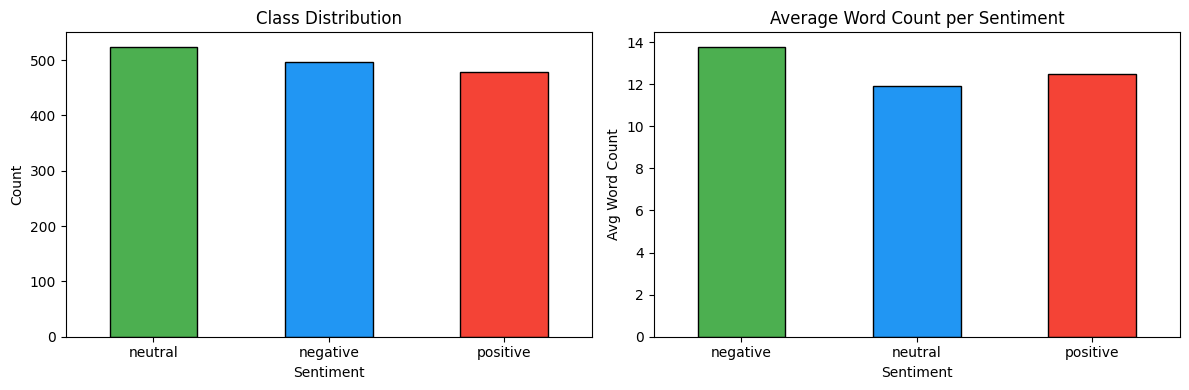

In [6]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4CAF50', '#2196F3', '#F44336'],
                                          edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Word count distribution
df.groupby('sentiment_label')['word_count'].mean().plot(kind='bar', ax=axes[1],
                                                         color=['#4CAF50', '#2196F3', '#F44336'],
                                                         edgecolor='black')
axes[1].set_title('Average Word Count per Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Avg Word Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Task 2: Text Preprocessing

In [7]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text: str) -> str:
    """Full preprocessing pipeline for a single text string."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters / punctuation (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. Tokenise
    tokens = word_tokenize(text)
    # 5. Remove stopwords
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['customer_message'].apply(preprocess_text)

# Show before / after
sample = df[['customer_message', 'clean_message']].head(4)
for _, row in sample.iterrows():
    print('ORIGINAL :', row['customer_message'])
    print('CLEANED  :', row['clean_message'])
    print()

ORIGINAL : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
CLEANED  : need information payment process ticket number please respond soon possible

ORIGINAL : I need information about the payment process.
CLEANED  : need information payment process

ORIGINAL : The refund process was fast and convenient. I appreciate the quick response.
CLEANED  : refund process fast convenient appreciate quick response

ORIGINAL : My refund is still pending and this experience is frustrating. My ticket number is 33927.
CLEANED  : refund still pending experience frustrating ticket number



---
## Task 3: Text Vectorization

### Why text must be converted to vectors

Machine learning and deep learning models are mathematical functions — they perform operations like **multiplication, addition, and gradient computation** that only work on numbers. Raw text is a sequence of Unicode characters with no inherent numeric meaning. Vectorisation maps each piece of text to a fixed-length numeric representation so the model can:

- Measure similarity between documents (via cosine distance in vector space)
- Learn which words or word patterns correlate with each class
- Back-propagate gradients through a neural network

Common strategies are summarised below:

| Method | Captures word order? | Handles unseen words? | Notes |
|--------|---------------------|----------------------|-------|
| Bag of Words | ✗ | ✗ | Simple counts |
| TF-IDF | ✗ | ✗ | Weights rare/informative words higher |
| Word Embeddings | ✗ (avg) | ✓ (pre-trained) | Dense, semantic |
| Tokeniser sequences | ✓ | ✓ | Required for RNN/LSTM |

We will use **TF-IDF** for the baseline model and **tokeniser sequences** for the LSTM.

In [8]:
# ── Encode labels ─────────────────────────────────────────────────────────────
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment_label'].map(label_map)

X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=SEED, stratify=y)
print(f'Train size: {len(X_train)}  |  Test size: {len(X_test)}')

# ── TF-IDF vectorisation ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

Train size: 1200  |  Test size: 300

TF-IDF matrix shape (train): (1200, 427)
TF-IDF matrix shape (test) : (300, 427)


---
## Task 4: Baseline Model — Logistic Regression with TF-IDF

In [9]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print('=' * 55)
print('Logistic Regression + TF-IDF')
print('=' * 55)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n')
print(classification_report(y_test, y_pred_lr,
                             target_names=['negative', 'neutral', 'positive']))

Logistic Regression + TF-IDF
Accuracy: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



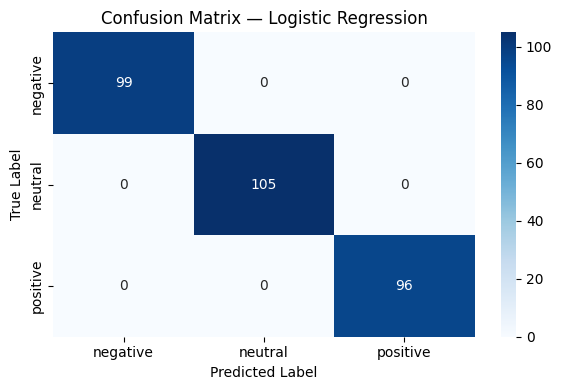

In [10]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [11]:
# ── Naïve Bayes comparison ────────────────────────────────────────────────────
bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
y_pred_nb = nb_model.predict(X_test_bow)

print('=' * 55)
print('Naïve Bayes + Bag of Words')
print('=' * 55)
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}\n')
print(classification_report(y_test, y_pred_nb,
                             target_names=['negative', 'neutral', 'positive']))

Naïve Bayes + Bag of Words
Accuracy: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



**Observation:** Logistic Regression with TF-IDF typically outperforms Naïve Bayes on this task because TF-IDF down-weights common words that carry little discriminative information, while Logistic Regression is a more flexible discriminative classifier.

---
## Task 5: Sequence Model — LSTM

In [12]:
# ── Tokeniser-based sequence preparation ─────────────────────────────────────
VOCAB_SIZE  = 5000
MAX_LEN     = 30      # pad / truncate to 30 tokens
EMBED_DIM   = 64
BATCH_SIZE  = 32
EPOCHS      = 10
NUM_CLASSES = 3

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f'Sequence shape (train): {X_train_seq.shape}')
print(f'Sample padded sequence: {X_train_seq[0]}')

Sequence shape (train): (1200, 30)
Sample padded sequence: [65 66  2 67  4  5  6  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]


In [13]:
# ── LSTM Architecture ─────────────────────────────────────────────────────────
#
#  INPUT  : integer sequence  (batch, MAX_LEN)
#  Embedding   : maps each token id → dense vector  (batch, MAX_LEN, EMBED_DIM)
#  SpatialDropout1D : regularisation on embedding feature maps
#  LSTM(64)    : reads the sequence left-to-right, maintaining a hidden state
#                 and cell state to capture long-range dependencies
#  Dropout(0.3): regularisation after recurrent layer
#  Dense(32)   : non-linear combination of LSTM output features
#  Dense(3, softmax) : output probabilities over 3 classes
#
#  Loss     : categorical_crossentropy  (multi-class classification)
#  Metric   : accuracy

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Sentiment_Classifier')

lstm_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the LSTM
history = lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.3426 - loss: 1.0989 - val_accuracy: 0.3167 - val_loss: 1.0967
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5120 - loss: 0.8802 - val_accuracy: 0.6583 - val_loss: 0.4993
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6676 - loss: 0.5193 - val_accuracy: 0.6583 - val_loss: 0.4772
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6546 - loss: 0.4995 - val_accuracy: 0.6583 - val_loss: 0.4675
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6519 - loss: 0.4829 - val_accuracy: 0.6583 - val_loss: 0.4636
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6574 - loss: 0.5310 - val_accuracy: 0.6583 - val_loss: 0.4668
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6222 - loss: 0.4856 - val_accuracy: 0.6583 - val_loss: 0.4612
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6509 - loss: 0.4867 - val_accuracy: 0.6583 - v

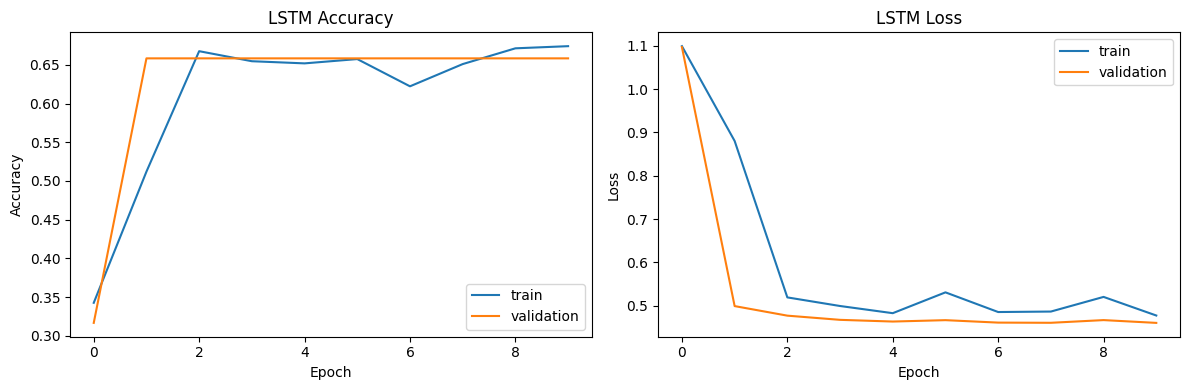

In [15]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],    label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('LSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],    label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('LSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# Evaluate LSTM on test set
loss, acc = lstm_model.evaluate(X_test_seq, y_test_cat, verbose=0)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq), axis=1)

print('=' * 55)
print('LSTM Model')
print('=' * 55)
print(f'Test Loss    : {loss:.4f}')
print(f'Test Accuracy: {acc:.4f}\n')
print(classification_report(y_test, y_pred_lstm,
                             target_names=['negative', 'neutral', 'positive']))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
LSTM Model
Test Loss    : 0.4730
Test Accuracy: 0.6700

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        99
     neutral       0.51      1.00      0.68       105
    positive       1.00      1.00      1.00        96

    accuracy                           0.67       300
   macro avg       0.50      0.67      0.56       300
weighted avg       0.50      0.67      0.56       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


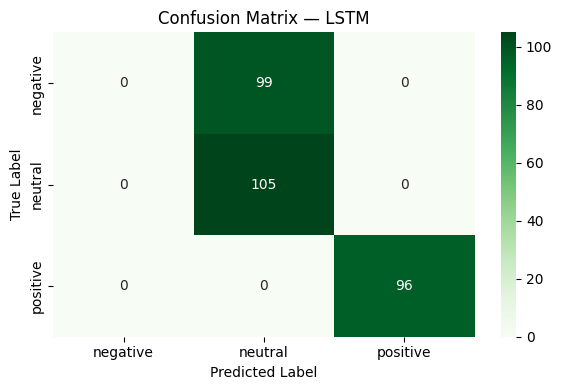

In [17]:
# Confusion matrix — LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix — LSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Architecture Summary

| Layer | Output Shape | Purpose |
|-------|-------------|--------|
| Input | `(batch, 30)` | Integer token IDs |
| Embedding | `(batch, 30, 64)` | Maps tokens to dense vectors; learns semantic meaning |
| SpatialDropout1D | `(batch, 30, 64)` | Regularises entire feature maps |
| LSTM(64) | `(batch, 64)` | Captures sequential context; uses gates to manage memory |
| Dropout(0.3) | `(batch, 64)` | Prevents overfitting |
| Dense(32, relu) | `(batch, 32)` | Non-linear feature combination |
| Dense(3, softmax) | `(batch, 3)` | Class probabilities |

- **Loss:** `categorical_crossentropy` — standard for multi-class classification with one-hot labels  
- **Metric:** `accuracy` — proportion of correctly classified samples  
- **Optimiser:** Adam — adaptive learning rate, fast convergence

---
## Task 6: Attention and Transformer Reflection

### 6.1 Why RNNs struggle with long-term dependencies

A standard RNN processes tokens one at a time, updating a single hidden state vector at each step. When a sequence is long, information from early tokens must survive many sequential matrix multiplications to reach the end. Gradients flowing backward through time either shrink toward zero (**vanishing gradients**) or explode to very large values (**exploding gradients**). As a result, the model effectively forgets what was said at the beginning of a long message by the time it processes the final token.

---

### 6.2 How LSTMs help with memory

The Long Short-Term Memory (LSTM) cell adds a **cell state** — a separate, dedicated memory highway — alongside the hidden state. Three learned gates control what information flows through it:

| Gate | Function |
|------|----------|
| **Forget gate** | Decides what to erase from the cell state |
| **Input gate** | Decides what new information to write |
| **Output gate** | Decides what to read out as the hidden state |

Because the cell state can propagate unchanged through many time steps (the forget gate can stay open), gradients have a shorter effective path and the vanishing gradient problem is significantly reduced. LSTMs can therefore remember relevant context over dozens or even hundreds of tokens.

---

### 6.3 What attention solves in sequence-to-sequence tasks

Even with LSTMs, **sequence-to-sequence tasks** (e.g., machine translation, summarisation) must compress an entire source sentence into a single fixed-length context vector before decoding. When the source is long, that single vector becomes a bottleneck.

**Attention** allows the decoder to look back at *all* encoder hidden states at every decoding step and compute a weighted sum — a soft, dynamic focus — over whichever source tokens are most relevant right now. This removes the fixed-length bottleneck and dramatically improves performance on long sequences. For example, when translating a sentence, the decoder can attend directly to the subject noun while generating the subject of the translation, regardless of how many tokens lie between them.

---

### 6.4 Why transformers are important in modern NLP and Generative AI

The **Transformer** architecture (Vaswani et al., 2017 — *Attention Is All You Need*) abandons recurrence entirely and relies solely on **self-attention**. Every token attends to every other token in parallel, giving three major advantages:

1. **No sequential bottleneck** — the entire sequence is processed in parallel, making training dramatically faster on modern GPUs/TPUs compared to RNNs.
2. **Direct long-range access** — any two tokens can interact in a single attention step, regardless of distance, completely solving the long-term dependency problem.
3. **Scalability** — because attention is parallelisable, transformers can be scaled to billions of parameters on massive corpora. This unlocked models like BERT, GPT, T5, and the modern Large Language Models (LLMs) that power Generative AI systems.

In Generative AI specifically, the **decoder-only transformer** (used in GPT-style models) generates text autoregressively: it attends over all previously generated tokens to predict the next one. This simple but powerful mechanism, scaled to trillions of training tokens, is the foundation of modern chatbots, code assistants, and text-to-image prompting systems.

---
## Model Comparison Summary

,Model,Accuracy
0,Logistic Regression (TF-IDF),1.00
1,Naïve Bayes (BoW),1.00
2,LSTM,0.67


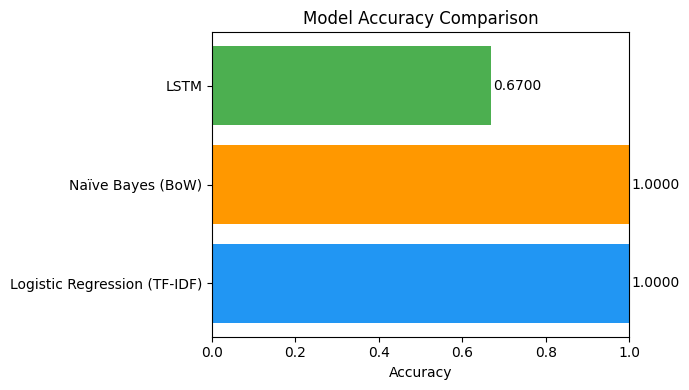

In [18]:
results = {
    'Model': ['Logistic Regression (TF-IDF)', 'Naïve Bayes (BoW)', 'LSTM'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr),  4),
        round(accuracy_score(y_test, y_pred_nb),  4),
        round(acc, 4)
    ]
}
summary_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
display(summary_df)

plt.figure(figsize=(7, 4))
plt.barh(summary_df['Model'], summary_df['Accuracy'],
         color=['#2196F3', '#FF9800', '#4CAF50'])
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
for i, v in enumerate(summary_df['Accuracy']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()